In [ ]:
import math
import itertools
from typing import List, Dict, Tuple, Any, Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
sns.set(style="whitegrid")

# Libraries for linear regression and statistics
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# Load Dataset and Split Seasons

# Dataset path
dataset_path = "/content/drive/MyDrive/BAT RAT DATASET/merged_dataset.csv"

# Load dataset
df = pd.read_csv(dataset_path)
print("Columns in dataset:", df.columns.tolist())
print("Unique season values:", df['season'].unique())

# Convert to numeric if needed
df['season'] = df['season'].astype(str).str.strip()

# Split based on numeric season labels
df_winter = df[df['season'] == '0']
df_spring = df[df['season'] == '1']

# Save seasonal subsets
winter_csv_path = "/content/drive/MyDrive/BAT RAT DATASET/merged_winter.csv"
spring_csv_path = "/content/drive/MyDrive/BAT RAT DATASET/merged_spring.csv"

df_winter.to_csv(winter_csv_path, index=False)
df_spring.to_csv(spring_csv_path, index=False)

print("Winter dataset shape:", df_winter.shape)
print("Spring dataset shape:", df_spring.shape)

Columns in dataset: ['start_time', 'bat_landing_to_food', 'habit', 'rat_period_start', 'rat_period_end', 'seconds_after_rat_arrival', 'risk', 'reward', 'month_dataset1', 'sunset_time', 'hours_after_sunset_dataset1', 'season', 'rat_presence_duration_sec', 'time', 'month_dataset2', 'hours_after_sunset_dataset2', 'bat_landing_number', 'food_availability', 'rat_minutes', 'rat_arrival_number', 'rat_eating']
Unique season values: [0 1]
Winter dataset shape: (151, 21)
Spring dataset shape: (756, 21)


In [ ]:
response_var = "bat_landing_number"  # Correct column in merged dataset

candidate_predictors = [
    'seconds_after_rat_arrival', 'risk', 'reward',
                        'rat_minutes',
                        'food_availability', 'rat_eating',
                        'rat_arrival_number',
                        'rat_presence_duration_sec'  # optional, if available
]

# Keep only columns that exist in the dataset
candidate_predictors = [col for col in candidate_predictors if col in df.columns]

print("Response variable:", response_var)
print("Candidate predictors:", candidate_predictors)

Response variable: bat_landing_number
Candidate predictors: ['seconds_after_rat_arrival', 'risk', 'reward', 'rat_minutes', 'food_availability', 'rat_eating', 'rat_arrival_number', 'rat_presence_duration_sec']


In [ ]:
def _fit_and_score(X_train, X_test, y_train, y_test, predictors):
    lm = LinearRegression()
    lm.fit(X_train[predictors], y_train)
    yhat_test = lm.predict(X_test[predictors])
    yhat_train = lm.predict(X_train[predictors])

    r2_test = r2_score(y_test, yhat_test)
    r2_train = r2_score(y_train, yhat_train)
    mse_test = mean_squared_error(y_test, yhat_test)
    mae_test = mean_absolute_error(y_test, yhat_test)
    rmse_test = math.sqrt(mse_test)

    Xsm = sm.add_constant(X_train[predictors], has_constant="add")
    sm_model = sm.OLS(y_train, Xsm).fit()
    adj_r2_train = sm_model.rsquared_adj

    return {
        "predictors": predictors[:],
        "n_features": len(predictors),
        "r2_test": r2_test,
        "r2_train": r2_train,
        "adj_r2_train": adj_r2_train,
        "mse_test": mse_test,
        "rmse_test": rmse_test,
        "mae_test": mae_test
    }

def _all_subsets(features, min_k=1, max_k=None):
    if max_k is None:
        max_k = len(features)
    for r in range(min_k, max_k+1):
        for combo in itertools.combinations(features, r):
            yield list(combo)

def select_best_predictors_by_test_r2(dataset_path, response_var, candidate_predictors, test_size=0.4, random_state=42):
    df = pd.read_csv(dataset_path)
    df = df.dropna(subset=[response_var] + candidate_predictors)
    X = df[candidate_predictors]
    y = df[response_var]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    results = []
    for subset in _all_subsets(candidate_predictors):
        res = _fit_and_score(X_train, X_test, y_train, y_test, subset)
        results.append(res)

    ranking = pd.DataFrame(results).sort_values("r2_test", ascending=False).reset_index(drop=True)
    best_list = ranking.loc[0, "predictors"]
    return best_list, ranking

def print_ranking_table(ranking_df, top_n=5):
    display_df = ranking_df.head(top_n).copy()
    for col in ["r2_test", "r2_train", "adj_r2_train", "mse_test", "rmse_test", "mae_test"]:
        display_df[col] = display_df[col].round(4)
    print("\n===== Model Subset Ranking (sorted by best test R²) =====")
    print(display_df.to_string(index=False))

In [ ]:
def run_linear_workflow(data, response_var, predictor_vars, test_size=0.4, random_state=42, show_plots=True):
    df = pd.read_csv(data) if isinstance(data, str) else data.copy()
    df = df.dropna(subset=[response_var] + predictor_vars)
    X = df[predictor_vars]
    y = df[response_var]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = {
        "r2_test": r2_score(y_test, y_pred),
        "mse_test": mean_squared_error(y_test, y_pred),
        "mae_test": mean_absolute_error(y_test, y_pred),
        "rmse_test": math.sqrt(mean_squared_error(y_test, y_pred))
    }

    if show_plots:
        plt.figure(figsize=(6,6))
        plt.scatter(y_test, y_pred, alpha=0.7)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
        plt.title(f"Actual vs Predicted")
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.show()

    return {"model": model, "metrics": metrics, "y_test": y_test, "y_pred": y_pred}


Running Linear Regression for WINTER dataset (Merged Dataset)

===== Model Subset Ranking (sorted by best test R²) =====
                                                                           predictors  n_features  r2_test  r2_train  adj_r2_train  mse_test  rmse_test  mae_test
                           [food_availability, rat_eating, rat_presence_duration_sec]           3   0.2050    0.0798        0.0477  309.4985    17.5926   13.7523
                                              [rat_eating, rat_presence_duration_sec]           2   0.1976    0.0796        0.0584  312.3785    17.6742   13.8486
                           [seconds_after_rat_arrival, food_availability, rat_eating]           3   0.1676    0.0560        0.0231  324.0495    18.0014   13.9541
[seconds_after_rat_arrival, food_availability, rat_eating, rat_presence_duration_sec]           4   0.1666    0.0852        0.0422  324.4252    18.0118   14.3605
                   [seconds_after_rat_arrival, rat_eating, rat_prese

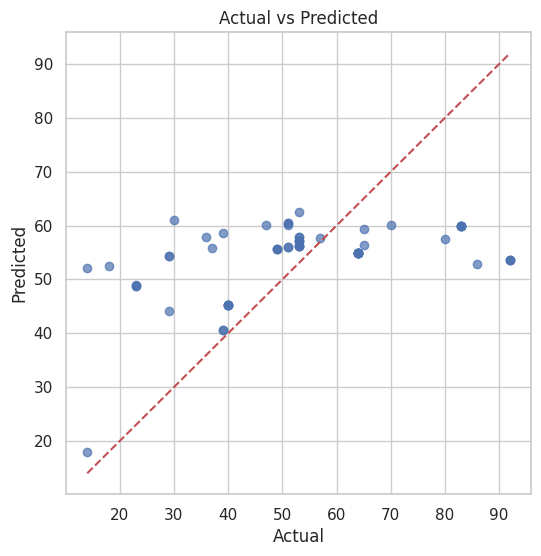

In [ ]:
print("\n============================")
print("Running Linear Regression for WINTER dataset (Merged Dataset)")
print("============================")

# Pick best predictors based on test R²
best_predictors_winter, ranking_winter = select_best_predictors_by_test_r2(
    winter_csv_path,
    response_var,
    candidate_predictors,
    test_size=0.4,
    random_state=42
)

# Display the ranking table
print_ranking_table(ranking_winter, top_n=5)

# Run linear regression workflow
results_winter = run_linear_workflow(
    winter_csv_path,
    response_var,
    best_predictors_winter,
    test_size=0.4,
    random_state=42,
    show_plots=True  # Visualize results
)


Running Linear Regression for SPRING dataset (Merged Dataset)

===== Model Subset Ranking (sorted by best test R²) =====
                                                                                 predictors  n_features  r2_test  r2_train  adj_r2_train  mse_test  rmse_test  mae_test
                           [rat_minutes, food_availability, rat_eating, rat_arrival_number]           4   0.0558    0.0847        0.0765  479.0654    21.8876   17.4776
                   [reward, rat_minutes, food_availability, rat_eating, rat_arrival_number]           5   0.0557    0.0849        0.0747  479.1155    21.8887   17.5120
                               [reward, rat_minutes, food_availability, rat_arrival_number]           4   0.0539    0.0773        0.0691  480.0504    21.9101   17.4844
                                       [rat_minutes, food_availability, rat_arrival_number]           3   0.0538    0.0771        0.0710  480.0999    21.9112   17.4624
[seconds_after_rat_arrival, rat_minute

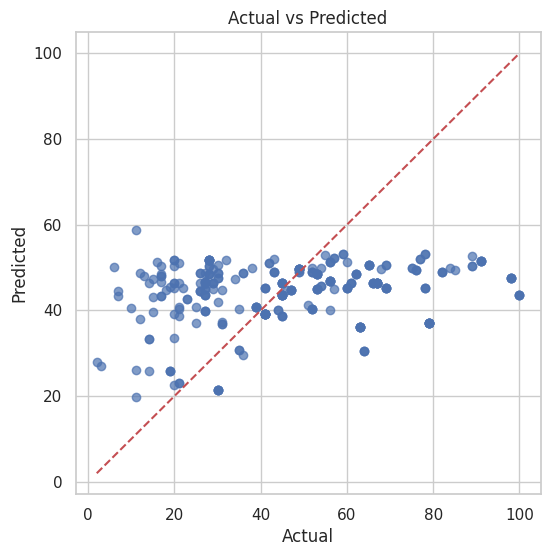

In [ ]:
print("\n============================")
print("Running Linear Regression for SPRING dataset (Merged Dataset)")
print("============================")

# Pick best predictors based on test R²
best_predictors_winter, ranking_winter = select_best_predictors_by_test_r2(
    spring_csv_path,
    response_var,
    candidate_predictors,
    test_size=0.4,
    random_state=42
)

# Display the ranking table
print_ranking_table(ranking_winter, top_n=5)

# Run linear regression workflow
results_spring = run_linear_workflow(
    spring_csv_path,
    response_var,
    best_predictors_winter,
    test_size=0.4,
    random_state=42,
    show_plots=True  # Visualize results
)

In [ ]:
# Compute NRMAC (Normalized MAE) for Winter and Spring
nrmse_winter = results_winter["metrics"]["mae_test"] / (results_winter["y_test"].max() - results_winter["y_test"].min())
nrmse_spring = results_spring["metrics"]["mae_test"] / (results_spring["y_test"].max() - results_spring["y_test"].min())

# Create metrics comparison DataFrame
metrics_comparison = pd.DataFrame({
    "Season": ["Winter", "Spring"],
    "R2_test": [results_winter["metrics"]["r2_test"], results_spring["metrics"]["r2_test"]],
    "MSE_test": [results_winter["metrics"]["mse_test"], results_spring["metrics"]["mse_test"]],
    "RMSE_test": [results_winter["metrics"]["rmse_test"], results_spring["metrics"]["rmse_test"]],
    "MAE_test": [results_winter["metrics"]["mae_test"], results_spring["metrics"]["mae_test"]],
    "NRMSE_test": [nrmse_winter, nrmse_spring]
})

print("===== Metrics Comparison: Winter vs Spring (Merged Dataset) =====")
print(metrics_comparison)

===== Metrics Comparison: Winter vs Spring (Merged Dataset) =====
   Season   R2_test    MSE_test  RMSE_test   MAE_test  NRMSE_test
0  Winter  0.204991  309.498494  17.592569  13.752320    0.176312
1  Spring  0.055792  479.065431  21.887563  17.477578    0.178343


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reload seasonal datasets
winter_csv_path = "/content/drive/MyDrive/BAT RAT DATASET/merged_winter.csv"
spring_csv_path = "/content/drive/MyDrive/BAT RAT DATASET/merged_spring.csv"

df_winter = pd.read_csv(winter_csv_path)
df_spring = pd.read_csv(spring_csv_path)

# Now compute descriptive statistics
response_var = "bat_landing_number"

winter_stats = df_winter[response_var].agg(['mean', 'median', 'var', 'std']).rename("Winter")
spring_stats = df_spring[response_var].agg(['mean', 'median', 'var', 'std']).rename("Spring")

descriptive_stats = pd.DataFrame([winter_stats, spring_stats])
print("===== Descriptive Statistics for Response Variable =====")
print(descriptive_stats)

===== Descriptive Statistics for Response Variable =====
             mean  median         var        std
Winter  53.245033    51.0  654.786225  25.588791
Spring  45.140212    43.0  569.212103  23.858166


/tmp/ipython-input-2296535891.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


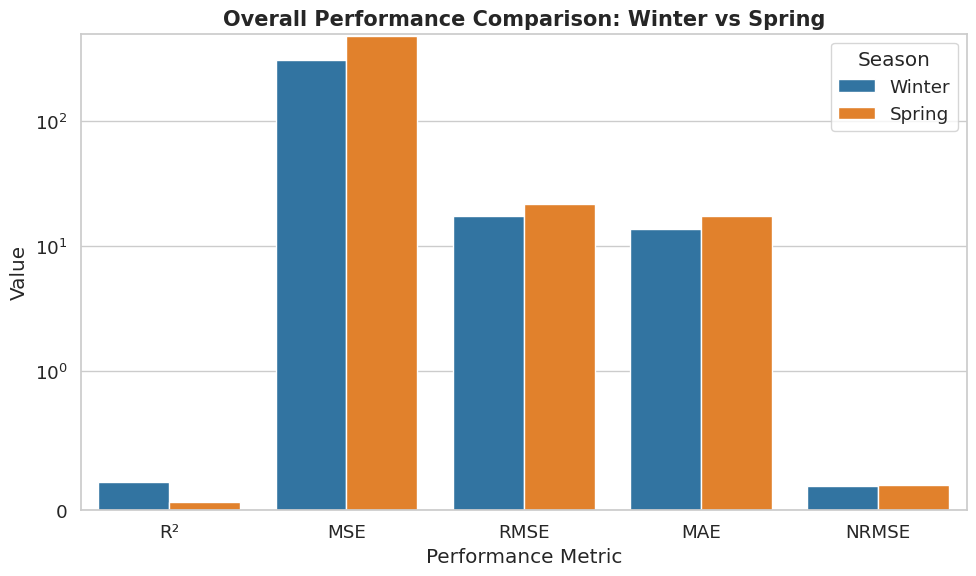

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Updated comparison dataframe
comparison_df = pd.DataFrame({
    "Metric": ["R²", "MSE", "RMSE", "MAE", "NRMSE"],
    "Winter": [0.204991, 309.498494, 17.592569, 13.752320, 0.176312],
    "Spring": [0.055792, 479.065431, 21.887563, 17.477578, 0.178343]
})

# Melt for seaborn
comparison_melted = comparison_df.melt(id_vars="Metric", var_name="Season", value_name="Value")

# Set plot style
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(10, 6))

# Define colors
colors = ["#1f77b4", "#ff7f0e"]

# Plot bars
ax = sns.barplot(
    data=comparison_melted,
    x="Metric",
    y="Value",
    hue="Season",
    palette=colors,
    dodge=True,
    ci=None
)

# Custom y-axis: symlog for large metrics
ax.set_yscale("symlog", linthresh=1)

ax.set_ylabel("Value")
ax.set_xlabel("Performance Metric")
plt.title("Overall Performance Comparison: Winter vs Spring", fontsize=15, weight="bold")
plt.legend(title="Season", loc="upper right")
plt.tight_layout()
plt.show()


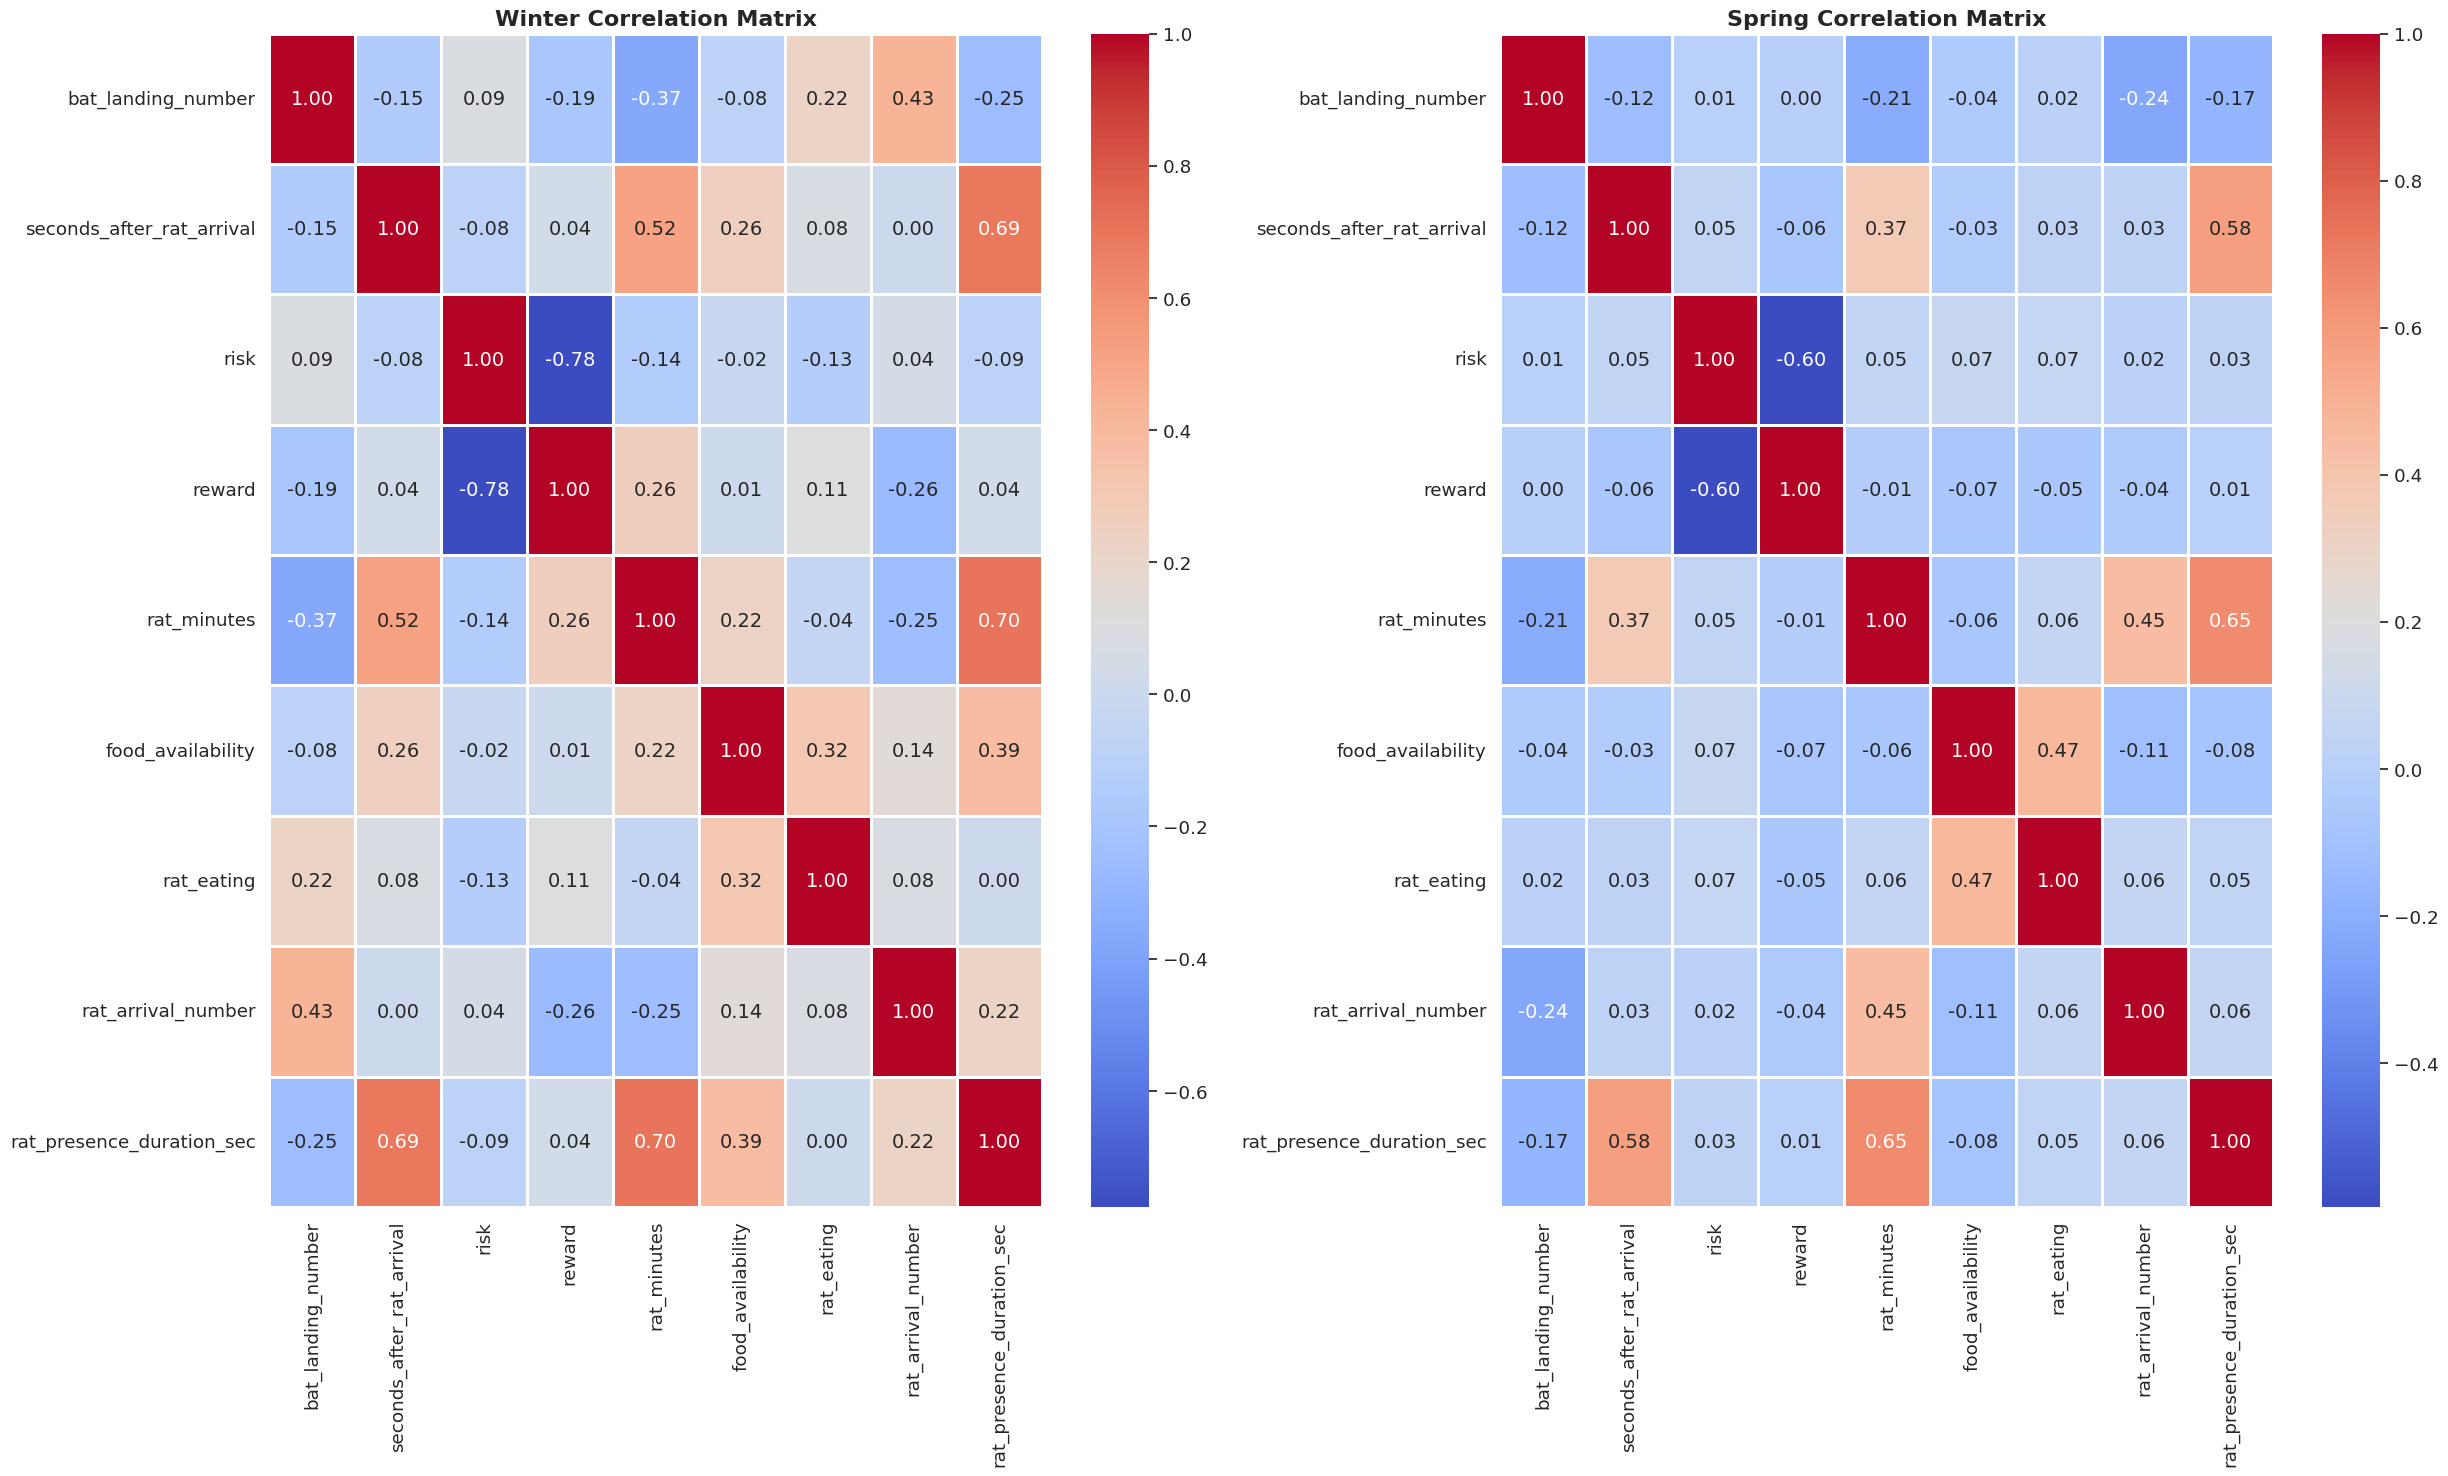

In [ ]:
# ===============================================
# Correlation Matrix Visualization for Winter & Spring
# ===============================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)

# Columns of interest
cols_of_interest = [response_var] + candidate_predictors

# Select only numeric columns for correlation
numeric_winter = df_winter[cols_of_interest].select_dtypes(include=["float64", "int64"])
numeric_spring = df_spring[cols_of_interest].select_dtypes(include=["float64", "int64"])

# Compute correlation matrices
corr_winter = numeric_winter.corr()
corr_spring = numeric_spring.corr()

# Create side-by-side plots with larger figure
fig, axes = plt.subplots(1, 2, figsize=(25, 15))  # Bigger figure

# --- Winter ---
sns.heatmap(
    corr_winter, annot=True, fmt=".2f", cmap="coolwarm",
    cbar=True, linewidths=1.0, ax=axes[0],
    annot_kws={"size": 14}  # Bigger numbers
)
axes[0].set_title("Winter Correlation Matrix", fontsize=16, fontweight="bold")

# --- Spring ---
sns.heatmap(
    corr_spring, annot=True, fmt=".2f", cmap="coolwarm",
    cbar=True, linewidths=1.0, ax=axes[1],
    annot_kws={"size": 14}  # Bigger numbers
)
axes[1].set_title("Spring Correlation Matrix", fontsize=16, fontweight="bold")

# Adjust layout for readability
plt.tight_layout()
plt.show()